# Assignment 2 - Poject 7 Mixed Precision Training Strategy for VAE and VQ-VAE


## Description
Variational Autoencoders (VAE) and Vector Quantized Variational Autoencoders (VQ-VAE) are powerful generative models used in the field of deep learning for unsupervised learning tasks. This project aims to compare the performance of these models on three benchmark datasets: CIFAR-10, MNIST, and Fashion-MNIST. A key aspect of this comparison will be the use of normal and mixed precision training approaches, which have implications for training efficiency and model accuracy.

### Objectives

 - Implement VAE and VQ-VAE models in a deep learning framework
 - Train and evaluate these models on CIFAR-10, MNIST, and Fashion-MNIST datasets
 - Compare the performance of each model using normal and mixed precision training methods.
- Analyze the effects of precision training on the efficiency and accuracy of the models.

### notes on approach - A

- implimentation
    - VAE and VQ-VAE
- train both on each dataset
- comparison
    - mixed vs normal precision training
- analysis 
    - generation quality and reconstruction quality
    - training efficency
    - accuacay and preformance trade-offs
    

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import json
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import os
import time
import pathlib as Path

import sys
import pandas as pd
from tqdm import tqdm

from torchvision import datasets, transforms
import torchvision.utils as vutils
from torch.utils.data import DataLoader

from dataclasses import dataclass
from typing import Tuple, Dict, Optional


### Config varables

In [4]:
DATA_DIR = "./data"
OUTPUT_DIR = "./outputs"

BATCH_SIZE = 128
NUM_WORKERS = 2
LEARNING_RATE = 1e-3
LATENT_DIM = 128
dev_EPOCHS = 10
prod_EPOCHS = 100

# VQ specific variables
code_book_size = 256
hidden_channels = 128
vq_nepoch = 1 #dev_EPOCHS

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [5]:
#Make sure GPU torch is instaled and available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
#Check if GPU is available and set device accordingly
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Using device: cuda
GPU: NVIDIA GeForce RTX 5060 Laptop GPU


In [6]:
import sys, torch

print("python exe:", sys.executable)
print("torch file:", torch.__file__)
print("torch version:", torch.__version__)
print("torch cuda:", torch.version.cuda)
print("cuda available:", torch.cuda.is_available())

python exe: c:\Users\Arnar\Documents\Github_repos\MLBAssignment2\.venv\Scripts\python.exe
torch file: c:\Users\Arnar\Documents\Github_repos\MLBAssignment2\.venv\Lib\site-packages\torch\__init__.py
torch version: 2.10.0+cu128
torch cuda: 12.8
cuda available: True


### Data Functions

In [7]:


def get_datasets(data_dir="./data", dataset_name="mnist"):
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])

    if dataset_name == "mnist":
        train_set = datasets.MNIST(root=data_dir, train=True, download=True, transform=transform)
        test_set = datasets.MNIST(root=data_dir, train=False, download=True, transform=transform)
        in_channels, input_size = 1, 28

    elif dataset_name == "fashion-mnist":
        train_set = datasets.FashionMNIST(root=data_dir, train=True, download=True, transform=transform)
        test_set = datasets.FashionMNIST(root=data_dir, train=False, download=True, transform=transform)
        in_channels, input_size = 1, 28

    elif dataset_name == "cifar10":
        train_set = datasets.CIFAR10(root=data_dir, train=True, download=True, transform=transform)
        test_set = datasets.CIFAR10(root=data_dir, train=False, download=True, transform=transform)
        in_channels, input_size = 3, 32

    else:
        raise ValueError(f"Unknown dataset: {dataset_name}")

    return train_set, test_set, in_channels, input_size

def get_dataloaders(data_dir="./data", dataset_name="mnist", batch_size=128, num_workers=2):
    train_set, test_set, in_channels, input_size = get_datasets(data_dir, dataset_name)

    train_loader = DataLoader(
        train_set, batch_size=batch_size, shuffle=True,
        num_workers=num_workers, pin_memory=True
    )
    test_loader = DataLoader(
        test_set, batch_size=batch_size, shuffle=False,
        num_workers=num_workers, pin_memory=True
    )

    return train_loader, test_loader, in_channels, input_size

In [8]:
def show_batch(images, n=8, title="Batch"):
    images = images[:n].cpu()
    grid = vutils.make_grid(images, nrow=n, padding=2)
    plt.figure(figsize=(n * 1.5, 2))
    plt.imshow(grid.permute(1, 2, 0).squeeze(), cmap="gray" if images.shape[1] == 1 else None)
    plt.title(title)
    plt.axis("off")
    plt.show()

### Fetch data

In [9]:
mnist_train, mnist_test, mnist_in_channels, mnist_input_size = get_dataloaders(
    data_dir=DATA_DIR,
    dataset_name="mnist",
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
)
fashion_mnist_train, fashion_mnist_test, fashion_mnist_in_channels, fashion_mnist_input_size = get_dataloaders(
    data_dir=DATA_DIR,
    dataset_name="fashion-mnist",
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
)
cifar10_train, cifar10_test, cifar10_in_channels, cifar10_input_size = get_dataloaders(
    data_dir=DATA_DIR,
    dataset_name="cifar10",
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


torch.Size([128, 1, 28, 28]) torch.Size([128])


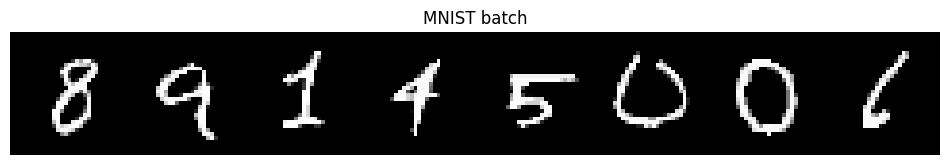

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


torch.Size([128, 1, 28, 28]) torch.Size([128])


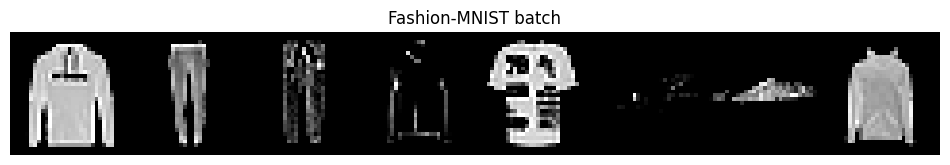

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


torch.Size([128, 3, 32, 32]) torch.Size([128])


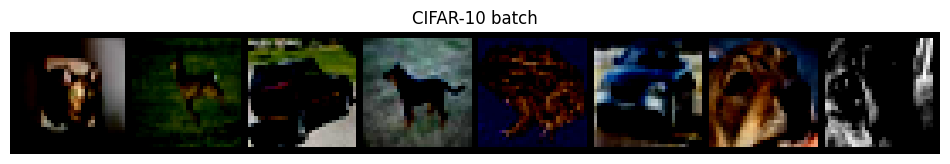

In [10]:
mnist_images, labels = next(iter(mnist_train))
fashion_mnist_images, labels1 = next(iter(fashion_mnist_train))
cifar10_images, labels2 = next(iter(cifar10_train))

print(mnist_images.shape, labels.shape)
show_batch(mnist_images, title="MNIST batch")
print(fashion_mnist_images.shape, labels1.shape)
show_batch(fashion_mnist_images, title="Fashion-MNIST batch")
print(cifar10_images.shape, labels2.shape)
show_batch(cifar10_images, title="CIFAR-10 batch")

### VQ-VAE Architecture and Training functions

In [11]:

@dataclass
class VQLossOutput:
    loss: torch.Tensor
    codebook_loss: torch.Tensor
    commitment_loss: torch.Tensor
    perplexity: torch.Tensor

class Encoder(nn.Module):
    def __init__(self, in_channels=3, hidden_channels=128, latent_dim=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, hidden_channels, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(hidden_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(hidden_channels, hidden_channels * 2, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(hidden_channels * 2),
            nn.ReLU(inplace=True),

            nn.Conv2d(hidden_channels * 2, latent_dim, kernel_size=3, stride=1, padding=1),
        )

    def forward(self, x):
        return self.net(x)
    
class Decoder(nn.Module):
    def __init__(self, latent_dim=256, hidden_channels=128, out_channels=3):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, hidden_channels * 2, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(hidden_channels * 2),
            nn.ReLU(inplace=True),

            nn.ConvTranspose2d(hidden_channels * 2, hidden_channels, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(hidden_channels),
            nn.ReLU(inplace=True),

            nn.ConvTranspose2d(hidden_channels, out_channels, kernel_size=4, stride=2, padding=1),
            nn.Tanh(),  # matches normalized inputs in [-1, 1]
        )

    def forward(self, z):
        return self.net(z)

class VectorQuantizer(nn.Module):
    def __init__(self, code_book_size=512, embedding_dim=256, commitment_cost=0.25):
        super().__init__()
        self.code_book_size = code_book_size
        self.embedding_dim = embedding_dim
        self.commitment_cost = commitment_cost
        self.embedding = nn.Embedding(self.code_book_size, embedding_dim)
        self.embedding.weight.data.uniform_(-1 / self.code_book_size, 1 / self.code_book_size)

    def forward(self, z):
        z = z.permute(0, 2, 3, 1).contiguous()
        z_shape = z.shape
        z_flattened = z.view(-1, self.embedding_dim)

        distances = (
            z_flattened.pow(2).sum(dim=1, keepdim=True)
            - 2 * z_flattened @ self.embedding.weight.t()
            + self.embedding.weight.pow(2).sum(dim=1)
        )

        encoding_indices = torch.argmin(distances, dim=1)
        quantized = self.embedding(encoding_indices).view(z_shape)

        commitment_loss = F.mse_loss(quantized.detach(), z)
        codebook_loss = F.mse_loss(quantized, z.detach())
        vq_loss = codebook_loss + self.commitment_cost * commitment_loss

        quantized = z + (quantized - z).detach()
        quantized = quantized.permute(0, 3, 1, 2).contiguous()
        encoding_indices = encoding_indices.view(z_shape[0], z_shape[1], z_shape[2])

        encodings_onehot = F.one_hot(
            encoding_indices.view(-1),
            num_classes=self.code_book_size
        ).float()
        avg_probs = encodings_onehot.mean(dim=0)
        perplexity = torch.exp(-(avg_probs * torch.log(avg_probs + 1e-10)).sum())

        return VQLossOutput(
            loss=vq_loss,
            codebook_loss=codebook_loss,
            commitment_loss=commitment_loss,
            perplexity=perplexity
        ), quantized, encoding_indices


class VQVAE(nn.Module):
    def __init__(self, in_channels=3, hidden_channels=128, latent_dim=256, code_book_size=512, commitment_cost=0.25):
        super().__init__()

        self.encoder = Encoder(in_channels=in_channels, hidden_channels=hidden_channels, latent_dim=latent_dim)
        self.vq = VectorQuantizer(code_book_size=code_book_size,embedding_dim=latent_dim,commitment_cost=commitment_cost)
        self.decoder = Decoder(latent_dim=latent_dim, hidden_channels=hidden_channels, out_channels=in_channels)

    def encode(self, x):
        z = self.encoder(x)
        vq_loss, quantized, encoding_indices = self.vq(z)
        return vq_loss, quantized, encoding_indices

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        vq_loss, quantized, encoding_indices = self.encode(x)
        recon = self.decode(quantized)
        return recon, vq_loss, quantized, encoding_indices
    



def evaluate_vqvae(model, dataloader, device, use_mixed_precision=False):
    model.eval()

    total_recon_loss = 0.0
    total_vq_loss = 0.0
    total_loss = 0.0

    total_code_counts = torch.zeros(model.vq.code_book_size, device=device)

    autocast_enabled = use_mixed_precision and torch.cuda.is_available()
    autocast_device = "cuda" if torch.cuda.is_available() else "cpu"

    with torch.no_grad():
        for data in tqdm(dataloader, leave=False, desc="Testing"):
            image = data[0].to(device)

            with torch.amp.autocast(device_type=autocast_device, enabled=autocast_enabled):
                recon_data, vq_output, quantized, encoding_indices = model(image)
                recon_loss = F.mse_loss(recon_data, image)
                loss = recon_loss + vq_output.loss

            total_recon_loss += recon_loss.item()
            total_vq_loss += vq_output.loss.item()
            total_loss += loss.item()

            flat_indices = encoding_indices.reshape(-1)
            counts = torch.bincount(flat_indices, minlength=model.vq.code_book_size).float()
            total_code_counts += counts

    num_batches = len(dataloader)

    avg_probs = total_code_counts / total_code_counts.sum()
    perplexity = torch.exp(-(avg_probs * torch.log(avg_probs + 1e-10)).sum()).item()
    used_codes = (total_code_counts > 0).sum().item()
    usage_fraction = used_codes / model.vq.code_book_size

    return {
        "recon_loss": total_recon_loss / num_batches,
        "vq_loss": total_vq_loss / num_batches,
        "loss": total_loss / num_batches,
        "perplexity": perplexity,
        "used_codes": used_codes,
        "usage_fraction": usage_fraction,
    }

def train_vqvae(model, train_loader, test_loader, device, epochs=5, learning_rate=1e-3,
                use_mixed_precision=False, scheduler_type="cosine", weight_decay=0.0):
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=learning_rate,
        weight_decay=weight_decay
    )

    startTime = time.perf_counter()

    scaler = torch.amp.GradScaler(
        "cuda",
        enabled=(use_mixed_precision and torch.cuda.is_available())
    )

    if scheduler_type == "cosine":
        lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer,
            T_max=epochs,
            eta_min=0
        )
    elif scheduler_type is None:
        lr_scheduler = None
    else:
        raise ValueError("scheduler_type must be 'cosine' or None")
    

    #===============================================================
    # Initalise metrics storage
    #===============================================================


    train_recon_loss_batch = []
    train_vq_loss_batch = []
    train_total_loss_batch = []

    train_recon_loss_epoch = []
    train_vq_loss_epoch = []
    train_total_loss_epoch = []

    test_recon_loss_epoch = []
    test_vq_loss_epoch = []
    test_total_loss_epoch = []

    gpu_mem_allocated_epoch = []
    gpu_mem_reserved_epoch = []
    gpu_mem_peak_epoch = []
    
    test_perplexity_epoch = []
    test_used_codes_epoch = []
    test_usage_fraction_epoch = []

    autocast_enabled = use_mixed_precision and torch.cuda.is_available()
    autocast_device = "cuda" if torch.cuda.is_available() else "cpu"

    pbar = tqdm(range(epochs), leave=False, desc="Epoch")

    for epoch in pbar:
        model.train()

        epoch_recon_loss = 0.0
        epoch_vq_loss = 0.0
        epoch_total_loss = 0.0

        for data in tqdm(train_loader, leave=False, desc="Training"):
            image = data[0].to(device)

            optimizer.zero_grad()

            with torch.amp.autocast(device_type=autocast_device, enabled=autocast_enabled):
                recon_data, vq_output, quantized, encoding_indices = model(image)
                recon_loss = F.mse_loss(recon_data, image)
                loss = recon_loss + vq_output.loss

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            train_recon_loss_batch.append(recon_loss.item())
            train_vq_loss_batch.append(vq_output.loss.item())
            train_total_loss_batch.append(loss.item())

            epoch_recon_loss += recon_loss.item()
            epoch_vq_loss += vq_output.loss.item()
            epoch_total_loss += loss.item()

        if lr_scheduler is not None:
            lr_scheduler.step()

        num_train_batches = len(train_loader)

        train_recon_avg = epoch_recon_loss / num_train_batches
        train_vq_avg = epoch_vq_loss / num_train_batches
        train_total_avg = epoch_total_loss / num_train_batches

        train_recon_loss_epoch.append(train_recon_avg)
        train_vq_loss_epoch.append(train_vq_avg)
        train_total_loss_epoch.append(train_total_avg)

        if torch.cuda.is_available():
            torch.cuda.synchronize()
            gpu_mem_allocated_epoch.append(torch.cuda.memory_allocated() / 1024**2)
            gpu_mem_reserved_epoch.append(torch.cuda.memory_reserved() / 1024**2)
            gpu_mem_peak_epoch.append(torch.cuda.max_memory_allocated() / 1024**2)
            
        else:
            gpu_mem_allocated_epoch.append(0.0)
            gpu_mem_reserved_epoch.append(0.0)
            gpu_mem_peak_epoch.append(0.0)

        
        test_metrics = evaluate_vqvae(
            model=model,
            dataloader=test_loader,
            device=device,
            use_mixed_precision=use_mixed_precision,
        )

        test_recon_loss_epoch.append(test_metrics["recon_loss"])
        test_vq_loss_epoch.append(test_metrics["vq_loss"])
        test_total_loss_epoch.append(test_metrics["loss"])


        test_perplexity_epoch.append(test_metrics["perplexity"])
        test_used_codes_epoch.append(test_metrics["used_codes"])
        test_usage_fraction_epoch.append(test_metrics["usage_fraction"])

        pbar.set_postfix_str(f"train={train_total_avg:.4f}, test={test_metrics['loss']:.4f}")

    endTime = time.perf_counter()
    TrainingTime = endTime - startTime

    return {
        "model": model,
        "optimizer": optimizer,
        "train_recon_loss_batch": train_recon_loss_batch,
        "train_vq_loss_batch": train_vq_loss_batch,
        "train_total_loss_batch": train_total_loss_batch,
        "train_recon_loss": train_recon_loss_epoch,
        "train_vq_loss": train_vq_loss_epoch,
        "train_total_loss": train_total_loss_epoch,
        "test_recon_loss": test_recon_loss_epoch,
        "test_vq_loss": test_vq_loss_epoch,
        "test_total_loss": test_total_loss_epoch,
        "gpu_mem_allocated_mb": gpu_mem_allocated_epoch,
        "gpu_mem_reserved_mb": gpu_mem_reserved_epoch,
        "gpu_mem_peak_mb": gpu_mem_peak_epoch,
        "Training_time": TrainingTime,
        "test_perplexity": test_perplexity_epoch,
        "test_used_codes": test_used_codes_epoch,
        "test_usage_fraction": test_usage_fraction_epoch,
    }   






### VQ-VAE Evaluation Functions 

In [12]:

def show_vqvae_results(history, test_loader=None, device=None, dataset_name="mnist", images=None, num_images=8):
    model = history["model"]
    model.eval()

    print("Final Metrics")
    print(f"Training time [s]:    {history['Training_time']:.4f}")
    print(f"Final train recon loss:    {history['train_recon_loss'][-1]:.6f}")
    print(f"Final train vq loss:       {history['train_vq_loss'][-1]:.6f}")
    print(f"Final train total loss:    {history['train_total_loss'][-1]:.6f}")
    print(f"Final test recon loss:     {history['test_recon_loss'][-1]:.6f}")
    print(f"Final test vq loss:        {history['test_vq_loss'][-1]:.6f}")
    print(f"Final test total:     {history['test_total_loss'][-1]:.6f}")
    print(f"Final test perplexity:    {history['test_perplexity'][-1]:.6f}")
    print(f"Final used codes:         {history['test_used_codes'][-1]}")
    print(f"Final usage fraction:     {history['test_usage_fraction'][-1]:.6f}")

    if images is None:
        if test_loader is None or device is None:
            return
        images, _ = next(iter(test_loader))

    if device is None:
        raise ValueError("device must be provided when showing reconstructions")

    images = images[:num_images].to(device)

    with torch.no_grad():
        recon_data, vq_out, quantized, encoding_indices = model(images)

    images_vis = denormalize_tensor(images, dataset_name).clamp(0, 1).cpu()
    recon_vis = denormalize_tensor(recon_data, dataset_name).clamp(0, 1).cpu()

    fig, axes = plt.subplots(2, num_images, figsize=(2 * num_images, 4))

    for i in range(num_images):
        original = images_vis[i]
        reconstructed = recon_vis[i]

        if original.shape[0] == 1:
            axes[0, i].imshow(original.squeeze(0), cmap="gray")
            axes[1, i].imshow(reconstructed.squeeze(0), cmap="gray")
        else:
            axes[0, i].imshow(original.permute(1, 2, 0))
            axes[1, i].imshow(reconstructed.permute(1, 2, 0))

        axes[0, i].axis("off")
        axes[1, i].axis("off")

    axes[0, 0].set_ylabel("Original", fontsize=12)
    axes[1, 0].set_ylabel("Recon", fontsize=12)

    plt.tight_layout()
    plt.show()

    print(f"Last batch VQ loss:   {vq_out.loss.item():.6f}")
    print(f"Last batch perplexity:{vq_out.perplexity.item():.6f}")
    print(f"Quantized shape:      {tuple(quantized.shape)}")
    print(f"Encoding shape:       {tuple(encoding_indices.shape)}")

def denormalize_tensor(x, dataset_name="mnist"):
    if dataset_name in ["mnist", "fashion-mnist"]:
        mean = torch.tensor((0.5,), device=x.device).view(1, 1, 1, 1)
        std = torch.tensor((0.5,), device=x.device).view(1, 1, 1, 1)
    elif dataset_name == "cifar10":
        mean = torch.tensor((0.5, 0.5, 0.5), device=x.device).view(1, 3, 1, 1)
        std = torch.tensor((0.5, 0.5, 0.5), device=x.device).view(1, 3, 1, 1)
    else:
        raise ValueError(f"Unknown dataset: {dataset_name}")

    return x * std + mean

def moving_average(values, window=25):
    if window is None or window <= 1 or len(values) < window:
        return np.array(values)
    kernel = np.ones(window) / window
    return np.convolve(values, kernel, mode="valid")



def show_vqvae_curves(history, extra_info, smooth_window=25, skip_first_batches=0):
    
    dataset_name = extra_info.get("dataset", "unknown dataset")
    precision_name = extra_info.get("precision", "unknown precision")

    title_prefix = f"{dataset_name} - {precision_name}"

    fig, axes = plt.subplots(2, 3, figsize=(16, 8))

    # batch-level curves
    train_recon_batch = history["train_recon_loss_batch"][skip_first_batches:]
    train_vq_batch = history["train_vq_loss_batch"][skip_first_batches:]
    train_total_batch = history["train_total_loss_batch"][skip_first_batches:]

    axes[0, 0].plot(moving_average(train_recon_batch, smooth_window), label="Train Recon")
    axes[0, 0].set_title(f"{title_prefix}\nBatch Reconstruction Loss")
    axes[0, 0].set_xlabel("Batch")
    axes[0, 0].set_ylabel("Loss")
    axes[0, 0].legend()

    axes[0, 1].plot(moving_average(train_vq_batch, smooth_window), label="Train VQ")
    axes[0, 1].set_title(f"{title_prefix}\nBatch VQ Loss")
    axes[0, 1].set_xlabel("Batch")
    axes[0, 1].set_ylabel("Loss")
    axes[0, 1].legend()

    axes[0, 2].plot(moving_average(train_total_batch, smooth_window), label="Train Total")
    axes[0, 2].set_title(f"{title_prefix}\nBatch Total Loss")
    axes[0, 2].set_xlabel("Batch")
    axes[0, 2].set_ylabel("Loss")
    axes[0, 2].legend()

    # epoch-level curves
    epochs = np.arange(1, len(history["train_total_loss"]) + 1)

    axes[1, 0].plot(epochs, history["train_recon_loss"], label="Train Recon")
    axes[1, 0].plot(epochs, history["test_recon_loss"], label="Test Recon")
    axes[1, 0].set_title(f"{title_prefix}\nEpoch Reconstruction Loss")
    axes[1, 0].set_xlabel("Epoch")
    axes[1, 0].set_ylabel("Loss")
    axes[1, 0].legend()

    axes[1, 1].plot(epochs, history["train_vq_loss"], label="Train VQ")
    axes[1, 1].plot(epochs, history["test_vq_loss"], label="Test VQ")
    axes[1, 1].set_title(f"{title_prefix}\nEpoch VQ Loss")
    axes[1, 1].set_xlabel("Epoch")
    axes[1, 1].set_ylabel("Loss")
    axes[1, 1].legend()

    axes[1, 2].plot(epochs, history["train_total_loss"], label="Train Total")
    axes[1, 2].plot(epochs, history["test_total_loss"], label="Test Total")
    axes[1, 2].set_title(f"{title_prefix}\nEpoch Total Loss")
    axes[1, 2].set_xlabel("Epoch")
    axes[1, 2].set_ylabel("Loss")
    axes[1, 2].legend()

    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.plot(history["gpu_mem_allocated_mb"], label="Allocated")
    plt.plot(history["gpu_mem_reserved_mb"], label="Reserved")
    plt.plot(history["gpu_mem_peak_mb"], label="Peak allocated")
    plt.xlabel("Epoch")
    plt.ylabel("Memory (MB)")
    plt.title(f"{title_prefix}\nGPU Memory Usage")
    plt.legend()
    plt.show()


def show_vqvae_total_loss(history, extra_info, smooth_window=25, skip_first_batches=0):
    dataset_name = extra_info.get("dataset", "unknown dataset")
    precision_name = extra_info.get("precision", "unknown precision")

    title_prefix = f"{dataset_name} - {precision_name}"

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # batch-level total loss
    train_total_batch = history["train_total_loss_batch"][skip_first_batches:]
    axes[0].plot(moving_average(train_total_batch, smooth_window), label="Train Total")
    axes[0].set_title(f"{title_prefix}\nBatch Total Loss")
    axes[0].set_xlabel("Batch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()

    # epoch-level total loss
    epochs = np.arange(1, len(history["train_total_loss"]) + 1)
    axes[1].plot(epochs, history["train_total_loss"], label="Train Total")
    axes[1].plot(epochs, history["test_total_loss"], label="Test Total")
    axes[1].set_title(f"{title_prefix}\nEpoch Total Loss")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss")
    axes[1].legend()

    plt.tight_layout()
plt.show()

def print_vqvae_final_metrics(loaded_model, label):
    hist = loaded_model["history"]["model"]
    hist.eval()
    history = loaded_model["history"]

    print(f"Final Metrics {label}")
    print(f"Training time [s]:    {history['Training_time']:.4f}")
    print(f"Final train recon loss:    {history['train_recon_loss'][-1]:.6f}")
    print(f"Final train vq loss:       {history['train_vq_loss'][-1]:.6f}")
    print(f"Final train total loss:    {history['train_total_loss'][-1]:.6f}")
    print(f"Final test recon loss:     {history['test_recon_loss'][-1]:.6f}")
    print(f"Final test vq loss:        {history['test_vq_loss'][-1]:.6f}")
    print(f"Final test total:          {history['test_total_loss'][-1]:.6f}")
    print()

def plot_vqvae_test_total_loss_comparison(history_fp32, history_amp, title="Test Total Loss: FP32 vs Mixed Precision"):
    epochs_fp32 = np.arange(1, len(history_fp32["test_total_loss"]) + 1)
    epochs_amp = np.arange(1, len(history_amp["test_total_loss"]) + 1)

    plt.figure(figsize=(8, 5))
    plt.plot(epochs_fp32, history_fp32["test_total_loss"], label="FP32")
    plt.plot(epochs_amp, history_amp["test_total_loss"], label="Mixed Precision")

    plt.xlabel("Epoch")
    plt.ylabel("Test Total Loss")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()




### Save and load VQ-VAE model functions

In [13]:

def make_json_safe(obj):
    if isinstance(obj, dict):
        return {k: make_json_safe(v) for k, v in obj.items()}
    elif isinstance(obj, (list, tuple)):
        return [make_json_safe(v) for v in obj]
    elif isinstance(obj, torch.Tensor):
        if obj.ndim == 0:
            return obj.item()
        return obj.detach().cpu().tolist()
    else:
        return obj


def save_trained_vqvae(
    model,
    optimizer,
    history,
    save_dir="./saved_models",
    run_name="vqvae_run",
    model_config=None,
    best_model_state_dict=None,
    extra_info=None,
):
    save_dir = Path.Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)

    checkpoint_path = save_dir / f"{run_name}.pt"
    history_path = save_dir / f"{run_name}_history.json"

    checkpoint = {
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict() if optimizer is not None else None,
        "best_model_state_dict": best_model_state_dict,
        "history": history,
        "model_config": model_config if model_config is not None else {},
        "extra_info": extra_info if extra_info is not None else {},
    }

    torch.save(checkpoint, checkpoint_path)

    # remove non-JSON-safe objects from history export
    history_json = {
        k: v for k, v in history.items()
        if k not in ["model", "optimizer"]
    }

    with open(history_path, "w") as f:
        json.dump(
            {
                "history": make_json_safe(history_json),
                "model_config": make_json_safe(model_config if model_config is not None else {}),
                "extra_info": make_json_safe(extra_info if extra_info is not None else {}),
            },
            f,
            indent=2,
        )

    print(f"Saved checkpoint to: {checkpoint_path}")
    print(f"Saved history json to: {history_path}")

    return str(checkpoint_path), str(history_path)


def load_trained_vqvae(
    checkpoint_path,
    model_class,
    device="cpu",
    load_best=False,
):
    checkpoint = torch.load(
        checkpoint_path,
        map_location=device,
        weights_only=False,   # important fix
    )

    model_config = checkpoint.get("model_config", {})
    model = model_class(**model_config).to(device)

    if load_best and checkpoint.get("best_model_state_dict") is not None:
        model.load_state_dict(checkpoint["best_model_state_dict"])
    else:
        model.load_state_dict(checkpoint["model_state_dict"])

    optimizer_state = checkpoint.get("optimizer_state_dict", None)
    history = checkpoint.get("history", {})
    extra_info = checkpoint.get("extra_info", {})

    return {
        "model": model,
        "optimizer_state_dict": optimizer_state,
        "history": history,
        "model_config": model_config,
        "extra_info": extra_info,
    }


mnist_config = {
    "in_channels": mnist_in_channels,
    "hidden_channels": hidden_channels,
    "latent_dim": LATENT_DIM,
    "code_book_size": code_book_size,
    "commitment_cost": 0.25,
}

fashion_mnist_config = {
    "in_channels": fashion_mnist_in_channels,
    "hidden_channels": hidden_channels,
    "latent_dim": LATENT_DIM,
    "code_book_size": code_book_size,
    "commitment_cost": 0.25,
}

cifar_config = {
    "in_channels": cifar10_in_channels,
    "hidden_channels": hidden_channels,
    "latent_dim": LATENT_DIM,
    "code_book_size": code_book_size,
    "commitment_cost": 0.25,
}

## VQ-VAE implimentation

In [14]:
VQvae_net_mnist = VQVAE(in_channels=mnist_in_channels, hidden_channels=hidden_channels, 
                        latent_dim=LATENT_DIM, code_book_size=code_book_size, commitment_cost=0.25).to(device)
VQvae_net_fashion_mnist = VQVAE(in_channels=fashion_mnist_in_channels, hidden_channels=hidden_channels, 
                                latent_dim=LATENT_DIM, code_book_size=code_book_size, commitment_cost=0.25).to(device)
VQvae_net_cifar = VQVAE(in_channels=cifar10_in_channels, hidden_channels=hidden_channels, 
                        latent_dim=LATENT_DIM, code_book_size=code_book_size, commitment_cost=0.25).to(device)



### Train and save VQ-VAE models

In [ ]:
history_mnist_FP = train_vqvae(
    model=VQvae_net_mnist,
    train_loader=mnist_train,
    test_loader=mnist_test,
    device=device,
    epochs=vq_nepoch,
    use_mixed_precision=False,
)

save_trained_vqvae(
    model=history_mnist_FP["model"],
    optimizer=history_mnist_FP["optimizer"],
    history=history_mnist_FP,
    save_dir="./saved_models/VQVAE/MNIST",
    run_name="vqvae_mnist_FP",
    model_config=mnist_config,
    extra_info={"dataset": "mnist", "precision": "fp32"}
)

Saved checkpoint to: saved_models\310226\vqvae_mnist_FP.pt
Saved history json to: saved_models\310226\vqvae_mnist_FP_history.json


('saved_models\\310226\\vqvae_mnist_FP.pt',
 'saved_models\\310226\\vqvae_mnist_FP_history.json')

In [ ]:
history_fashion_mnist_FP = train_vqvae(
    model=VQvae_net_fashion_mnist,
    train_loader=fashion_mnist_train,
    test_loader=fashion_mnist_test,
    device=device,
    epochs=vq_nepoch,
    use_mixed_precision=False,
)
save_trained_vqvae(
    model=history_fashion_mnist_FP["model"],
    optimizer=history_fashion_mnist_FP["optimizer"],
    history=history_fashion_mnist_FP,
    save_dir="./saved_models/VQVAE/FMNIST",
    run_name="vqvae_fashion_mnist_FP",
    model_config=fashion_mnist_config,
    extra_info={"dataset": "fashion-mnist", "precision": "fp32"}
)

Saved checkpoint to: saved_models\310226\vqvae_fashion_mnist_FP.pt
Saved history json to: saved_models\310226\vqvae_fashion_mnist_FP_history.json


('saved_models\\310226\\vqvae_fashion_mnist_FP.pt',
 'saved_models\\310226\\vqvae_fashion_mnist_FP_history.json')

In [ ]:
history_cifar_FP = train_vqvae(
    model=VQvae_net_cifar,
    train_loader=cifar10_train,
    test_loader=cifar10_test,
    device=device,
    epochs=vq_nepoch,
    use_mixed_precision=False,
)

save_trained_vqvae(
    model=history_cifar_FP["model"],
    optimizer=history_cifar_FP["optimizer"],
    history=history_cifar_FP,
    save_dir="./saved_models/VQVAE/CIFAR",
    run_name="vqvae_cifar10_FP",
    model_config=cifar_config,
    extra_info={"dataset": "cifar10", "precision": "fp32"}
)

Saved checkpoint to: saved_models\310226\vqvae_cifar10_FP.pt
Saved history json to: saved_models\310226\vqvae_cifar10_FP_history.json


('saved_models\\310226\\vqvae_cifar10_FP.pt',
 'saved_models\\310226\\vqvae_cifar10_FP_history.json')

Final Metrics
Training time [s]:    16.5480
Final train recon loss:    0.144331
Final train vq loss:       17.206742
Final train total loss:    17.351073
Final test recon loss:     0.057504
Final test vq loss:        1.274263
Final test total:     1.331767
Final test perplexity:    15.978774
Final used codes:         28
Final usage fraction:     0.109375


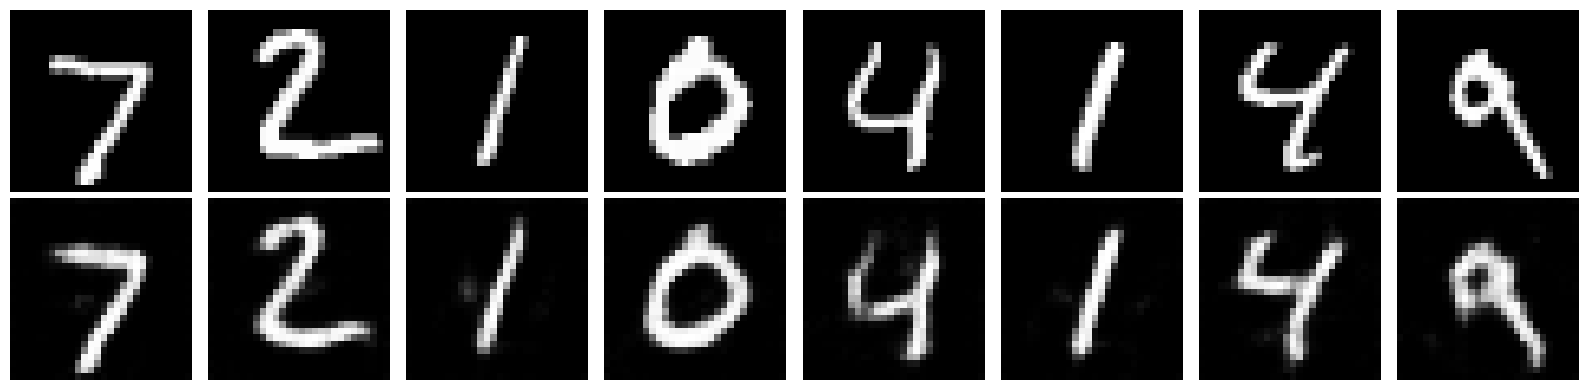

Last batch VQ loss:   0.924977
Last batch perplexity:16.209005
Quantized shape:      (8, 128, 7, 7)
Encoding shape:       (8, 7, 7)
-------------------------------------------------------------------------------
Final Metrics
Training time [s]:    15.3577
Final train recon loss:    0.134586
Final train vq loss:       4.737959
Final train total loss:    4.872545
Final test recon loss:     0.072049
Final test vq loss:        0.470990
Final test total:     0.543038
Final test perplexity:    14.296894
Final used codes:         38
Final usage fraction:     0.148438


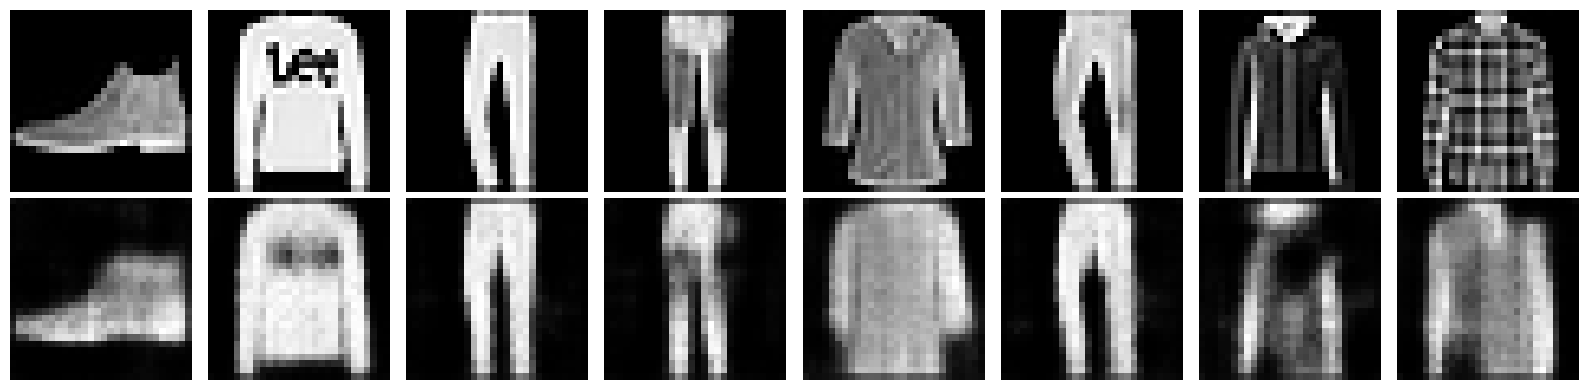

Last batch VQ loss:   0.692224
Last batch perplexity:13.687450
Quantized shape:      (8, 128, 7, 7)
Encoding shape:       (8, 7, 7)
-------------------------------------------------------------------------------
Final Metrics
Training time [s]:    24.7861
Final train recon loss:    0.097813
Final train vq loss:       10.947765
Final train total loss:    11.045578
Final test recon loss:     0.059129
Final test vq loss:        0.338440
Final test total:     0.397569
Final test perplexity:    17.566769
Final used codes:         41
Final usage fraction:     0.160156


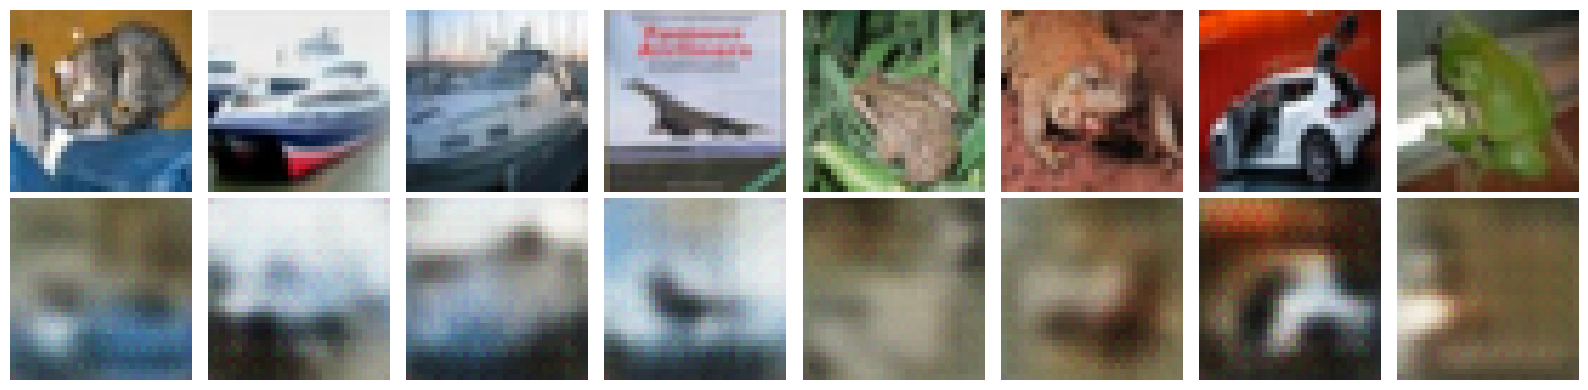

Last batch VQ loss:   0.274124
Last batch perplexity:15.070210
Quantized shape:      (8, 128, 8, 8)
Encoding shape:       (8, 8, 8)


In [18]:
show_vqvae_results(history=history_mnist_FP, test_loader=mnist_test, device=device, dataset_name="mnist", num_images=8)
print("-------------------------------------------------------------------------------")
show_vqvae_results(history=history_fashion_mnist_FP, test_loader=fashion_mnist_test, device=device, dataset_name="fashion-mnist", num_images=8)
print("-------------------------------------------------------------------------------")
show_vqvae_results(history=history_cifar_FP, test_loader=cifar10_test, device=device, dataset_name="cifar10", num_images=8)

In [ ]:
history_mnist_MP = train_vqvae(
    model=VQvae_net_mnist,
    train_loader=mnist_train,
    test_loader=mnist_test,
    device=device,
    epochs=vq_nepoch,
    use_mixed_precision=True,
)

save_trained_vqvae(
    model=history_mnist_MP["model"],
    optimizer=history_mnist_MP["optimizer"],
    history=history_mnist_MP,
    save_dir="./saved_models/VQVAE/MNIST",
    run_name="vqvae_mnist_MP",
    model_config=mnist_config,
    extra_info={"dataset": "mnist", "precision": "mixed"}
)

Saved checkpoint to: saved_models\310226\vqvae_mnist_MP.pt
Saved history json to: saved_models\310226\vqvae_mnist_MP_history.json


('saved_models\\310226\\vqvae_mnist_MP.pt',
 'saved_models\\310226\\vqvae_mnist_MP_history.json')

In [ ]:
history_fashion_mnist_MP = train_vqvae(
    model=VQvae_net_fashion_mnist,
    train_loader=fashion_mnist_train,
    test_loader=fashion_mnist_test,
    device=device,
    epochs=vq_nepoch,
    use_mixed_precision=True,
)

save_trained_vqvae(
    model=history_fashion_mnist_MP["model"],
    optimizer=history_fashion_mnist_MP["optimizer"],
    history=history_fashion_mnist_MP,
    save_dir="./saved_models/VQVAE/FMNIST",
    run_name="vqvae_fashion_mnist_MP",
    model_config=fashion_mnist_config,
    extra_info={"dataset": "fashion-mnist", "precision": "mixed"}
)

Saved checkpoint to: saved_models\310226\vqvae_fashion_mnist_MP.pt
Saved history json to: saved_models\310226\vqvae_fashion_mnist_MP_history.json


('saved_models\\310226\\vqvae_fashion_mnist_MP.pt',
 'saved_models\\310226\\vqvae_fashion_mnist_MP_history.json')

In [24]:
history_cifar_MP = train_vqvae(
    model=VQvae_net_cifar,
    train_loader=cifar10_train,
    test_loader=cifar10_test,
    device=device,
    epochs=vq_nepoch,
    use_mixed_precision=True,
)

save_trained_vqvae(
    model=history_cifar_MP["model"],
    optimizer=history_cifar_MP["optimizer"],
    history=history_cifar_MP,
    save_dir="./saved_models/VQVAE/CIFAR",
    run_name="vqvae_cifar10_MP",
    model_config=cifar_config,
    extra_info={"dataset": "cifar10", "precision": "mixed"}
)

Saved checkpoint to: saved_models\VQVAE\CIFAR\vqvae_cifar10_MP.pt
Saved history json to: saved_models\VQVAE\CIFAR\vqvae_cifar10_MP_history.json


('saved_models\\VQVAE\\CIFAR\\vqvae_cifar10_MP.pt',
 'saved_models\\VQVAE\\CIFAR\\vqvae_cifar10_MP_history.json')

Final Metrics
Training time [s]:    15.9340
Final train recon loss:    0.036766
Final train vq loss:       0.425491
Final train total loss:    0.462257
Final test recon loss:     0.024193
Final test vq loss:        0.160958
Final test total:     0.185150
Final test perplexity:    58.681774
Final used codes:         83
Final usage fraction:     0.324219


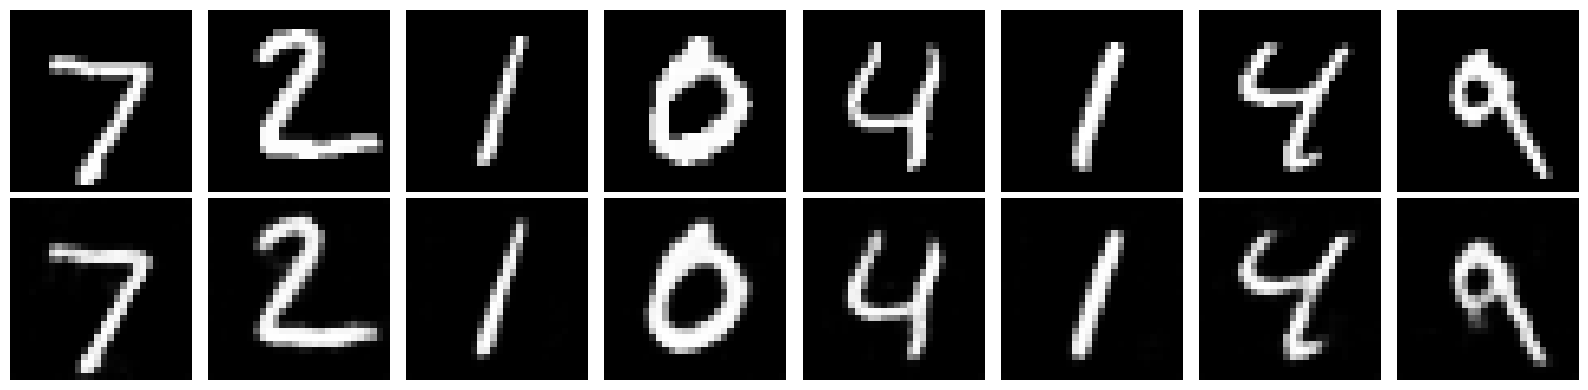

Last batch VQ loss:   0.116064
Last batch perplexity:54.292870
Quantized shape:      (8, 128, 7, 7)
Encoding shape:       (8, 7, 7)
-------------------------------------------------------------------------------
Final Metrics
Training time [s]:    16.0936
Final train recon loss:    0.055964
Final train vq loss:       0.288068
Final train total loss:    0.344032
Final test recon loss:     0.040042
Final test vq loss:        0.168671
Final test total:     0.208714
Final test perplexity:    32.708546
Final used codes:         57
Final usage fraction:     0.222656


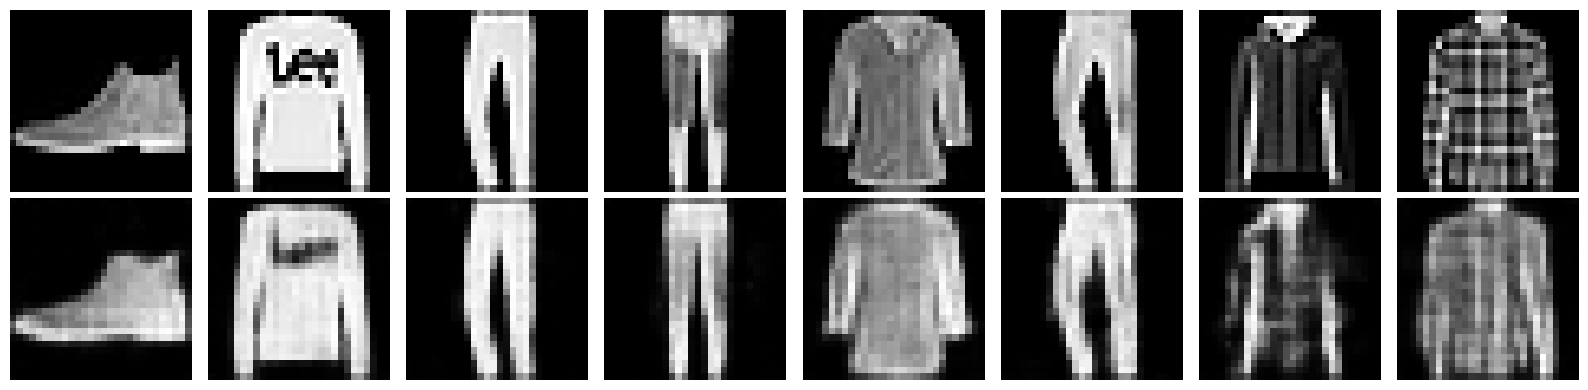

Last batch VQ loss:   0.226802
Last batch perplexity:32.812996
Quantized shape:      (8, 128, 7, 7)
Encoding shape:       (8, 7, 7)
-------------------------------------------------------------------------------
Final Metrics
Training time [s]:    27.8015
Final train recon loss:    0.034598
Final train vq loss:       0.124826
Final train total loss:    0.159424
Final test recon loss:     0.032504
Final test vq loss:        0.096104
Final test total:     0.128608
Final test perplexity:    40.171860
Final used codes:         59
Final usage fraction:     0.230469


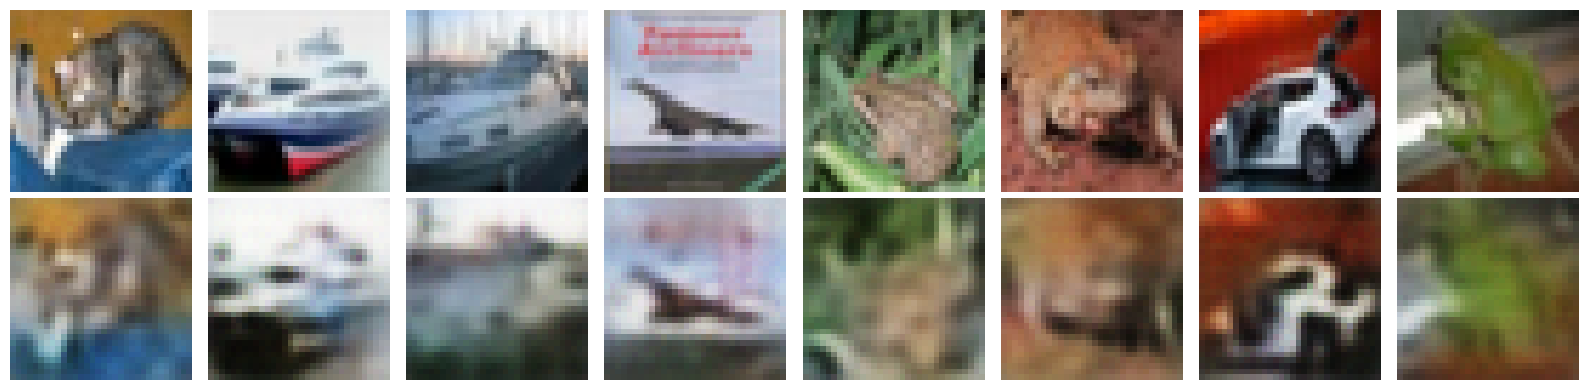

Last batch VQ loss:   0.093563
Last batch perplexity:35.996586
Quantized shape:      (8, 128, 8, 8)
Encoding shape:       (8, 8, 8)


In [25]:
show_vqvae_results(history=history_mnist_MP, test_loader=mnist_test, device=device, dataset_name="mnist", num_images=8)
print("-------------------------------------------------------------------------------")
show_vqvae_results(history=history_fashion_mnist_MP, test_loader=fashion_mnist_test, device=device, dataset_name="fashion-mnist", num_images=8)
print("-------------------------------------------------------------------------------")
show_vqvae_results(history=history_cifar_MP, test_loader=cifar10_test, device=device, dataset_name="cifar10", num_images=8)